In [1]:
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dataevaluator import DataEvaluator
from helper import evaluate_model, train_model
from scikeras.wrappers import KerasClassifier

from models.knn import KNN
from models.mlp import MLP
from models.logistic import LogReg
from models.cnn import CNN
from models.random_forest import RandomForest

In [3]:
data = DataEvaluator('dataset')
X_train, y_train, X_val, y_val, X_test, y_test = data.get_data()
print(X_train.shape, y_train.shape, X_val.shape, y_val.shape, X_test.shape, y_test.shape)
clothing_types = data.clothing_types

(51000, 784) (51000,) (9000, 784) (9000,) (10000, 784) (10000,)


In [4]:
# CNN data preprocessing

X_train_cnn = X_train.reshape((-1, 28, 28, 1)).astype("float32") / 255.0
X_val_cnn   = X_val.reshape((-1, 28, 28, 1)).astype("float32") / 255.0
X_test_cnn  = X_test.reshape((-1, 28, 28, 1)).astype("float32") / 255.0

print(X_train_cnn.shape)
print(X_val_cnn.shape)
print(X_test_cnn.shape)

(51000, 28, 28, 1)
(9000, 28, 28, 1)
(10000, 28, 28, 1)


## Data Exploration

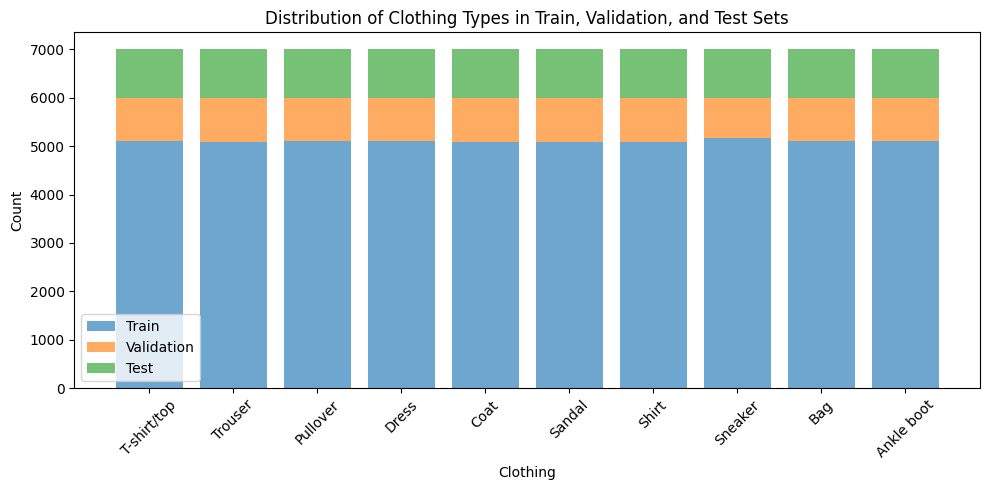

In [5]:
data.plot_clothing_distribution()
print()

# Model Initialization Logic Here

In [ ]:
l = LogReg()
k = KNN()
f = MLP()
c = CNN()
r = RandomForest()

# Training Models

In [7]:
ltime, _ = train_model(l, "Logistic Regression", X_train, y_train)
print(f"Training time for Logistic Regression: {ltime:.2f} seconds")

Training time for Logistic Regression: 87.50 seconds


In [8]:
kfit_time, _ = train_model(k, "kNN", X_train, y_train)
print(f"Training time for kNN: {kfit_time:.2f} seconds")

Training time for kNN: 0.04 seconds


In [9]:
ftime, _ = train_model(f, "MLP", X_train, y_train)
print(f"Training time for MLP: {ftime:.2f} seconds")

Training time for MLP: 72.16 seconds


Training time for Random Forest: 12.98 seconds


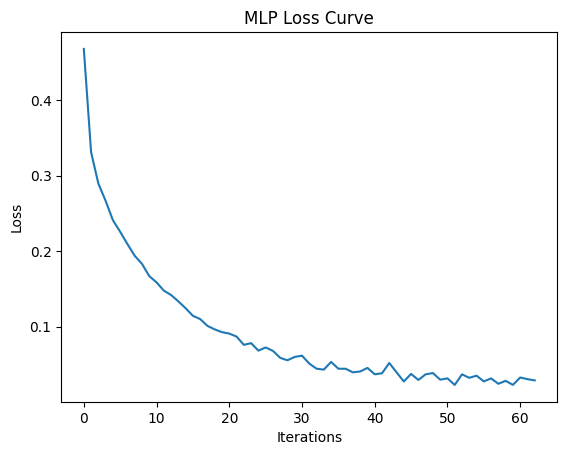

In [10]:
rtime, _ = train_model(r, "Random Forest", X_train, y_train)
print(f"Training time for Random Forest: {rtime:.2f} seconds")

plt.plot(f.classifier.loss_curve_)
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.title('MLP Loss Curve')
plt.savefig('figures/MLP_loss_curve.png')
plt.show()

Epoch 1/50


c:\Users\Oboes\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


399/399 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.6310 - loss: 1.0253
Epoch 2/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.7557 - loss: 0.6469
Epoch 3/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.7867 - loss: 0.5696
Epoch 4/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.8034 - loss: 0.5289
Epoch 5/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.8129 - loss: 0.4989
Epoch 6/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.8228 - loss: 0.4769
Epoch 7/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.8299 - loss: 0.4597
Epoch 8/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.8375 - loss: 0.4432
Epoch 9/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.8424 - loss: 0.4289
Epoch 10/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.8479 - loss: 0.4141
Epoch 11/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.8533 - loss: 0.4045
Epoch 12/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/ste

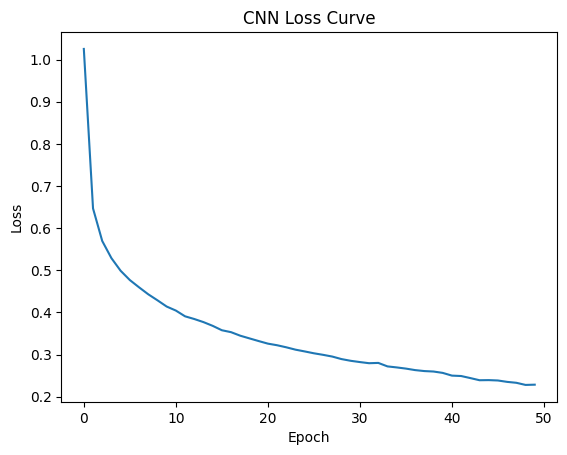

In [11]:
ctime, history = train_model(c, "CNN", X_train_cnn, y_train)
print(f"Training time for CNN: {ctime:.2f} seconds")

loss = c.history_["loss"]

plt.plot(loss)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Loss Curve")
plt.savefig('figures/CNN_loss_curve.png')
plt.show()

Logistic Regression Accuracy: 0.8402222222222222  Precision: 0.8388563240447852  Recall: 0.8402222222222222  F1 Score: 0.8392003941756991


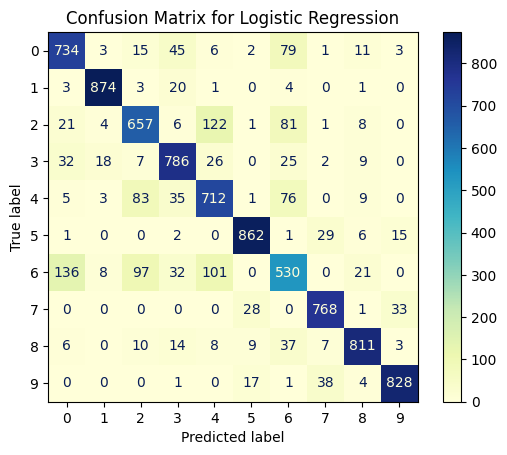

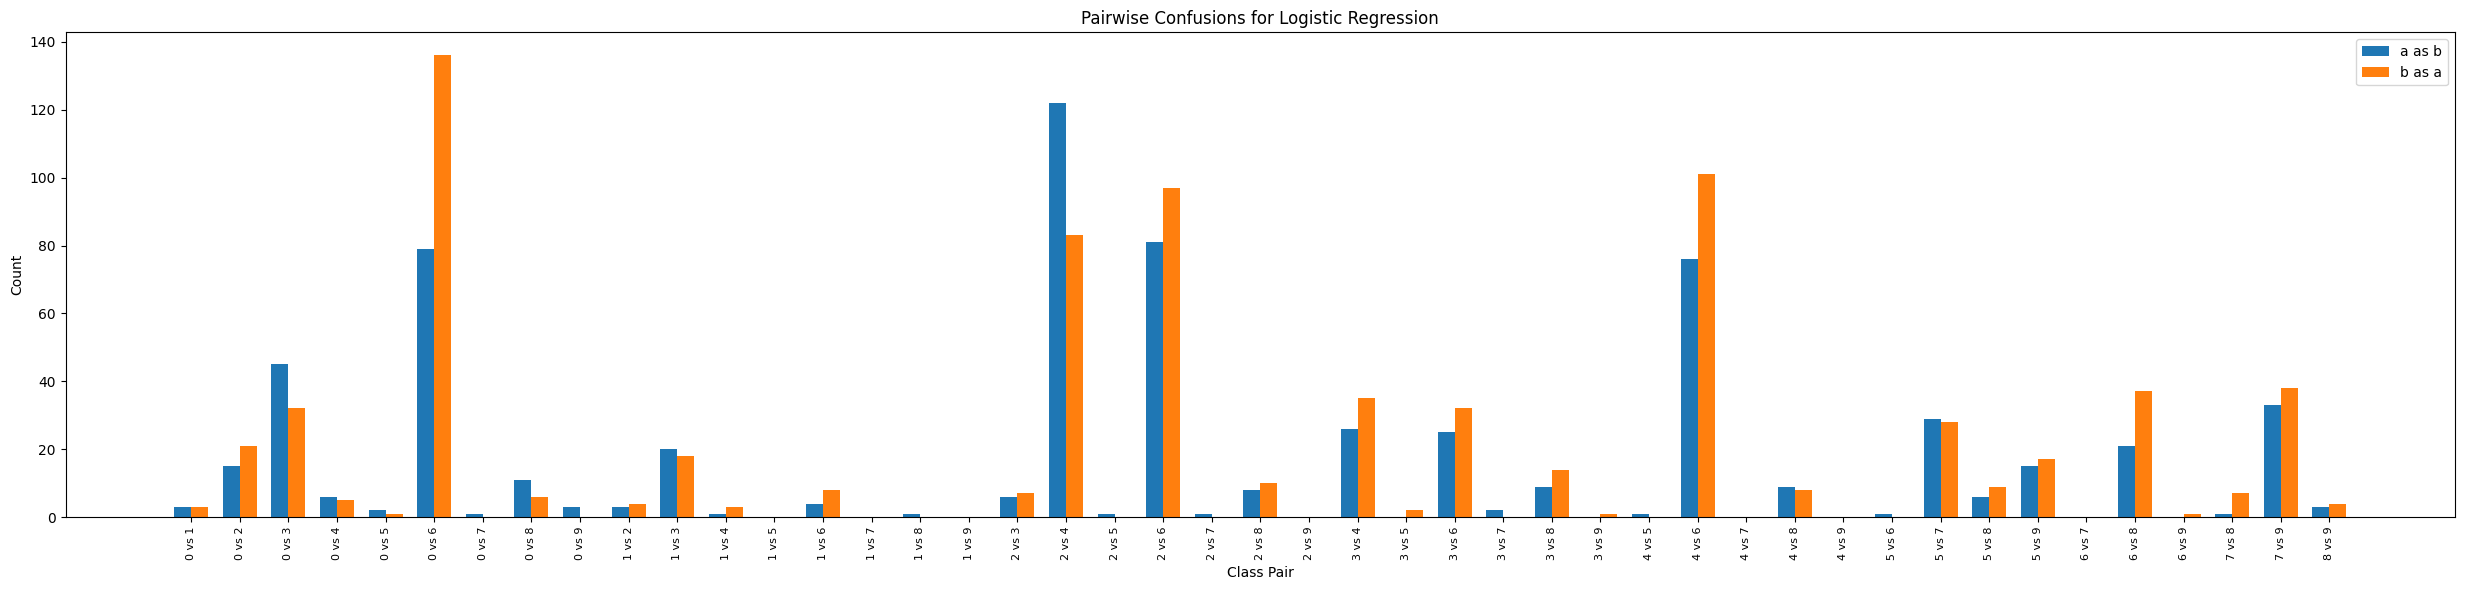

Logistic Regression class 0 AUC: 0.9793163315368171
Logistic Regression class 1 AUC: 0.9973963489702398
Logistic Regression class 2 AUC: 0.9703143630864389
Logistic Regression class 3 AUC: 0.9884737526404336
Logistic Regression class 4 AUC: 0.9732953607396402
Logistic Regression class 5 AUC: 0.9970989652318775
Logistic Regression class 6 AUC: 0.9329921178144087
Logistic Regression class 7 AUC: 0.9959805931191104
Logistic Regression class 8 AUC: 0.9894457734294752
Logistic Regression class 9 AUC: 0.9968989050823092


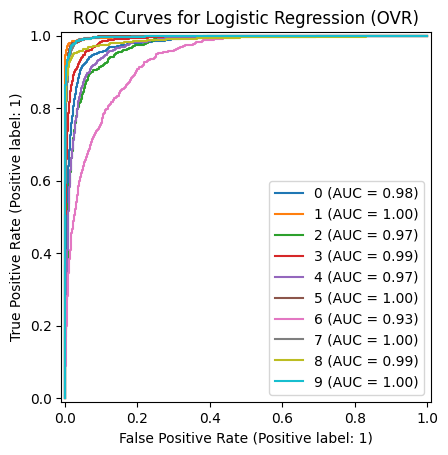

Logistic Regression pair 1 vs 5 AUC: 1.0
Logistic Regression pair 1 vs 7 AUC: 0.99990425277268
Logistic Regression pair 1 vs 9 AUC: 0.9998646692342266


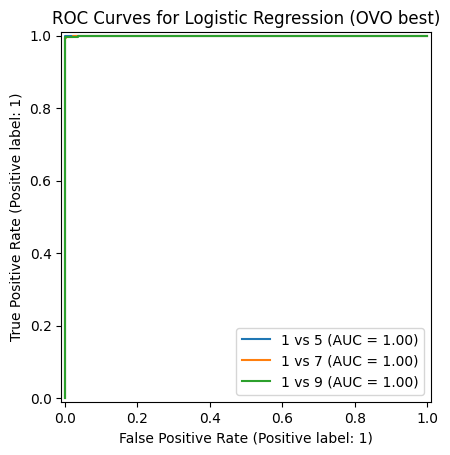

Logistic Regression pair 0 vs 6 AUC: 0.8337504133722153
Logistic Regression pair 2 vs 4 AUC: 0.8971224853577795
Logistic Regression pair 2 vs 6 AUC: 0.8260215376308606
Logistic Regression pair 4 vs 6 AUC: 0.852927342927343
Logistic Regression pair 0 vs 3 AUC: 0.9704914607390656


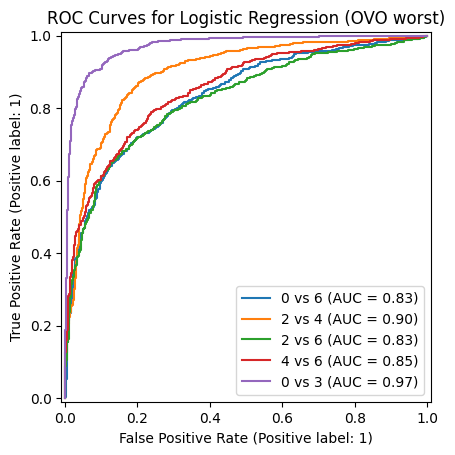

Validation time for Logistic Regression: 1.24 seconds


In [12]:
le, levals, letime = evaluate_model(l, "Logistic Regression", X_val, y_val, stage="validation", color="YlGnBu")
print(f"Validation time for Logistic Regression: {letime:.2f} seconds")

kNN Accuracy: 0.8502222222222222  Precision: 0.8532788767742758  Recall: 0.8502222222222222  F1 Score: 0.8499514169303215


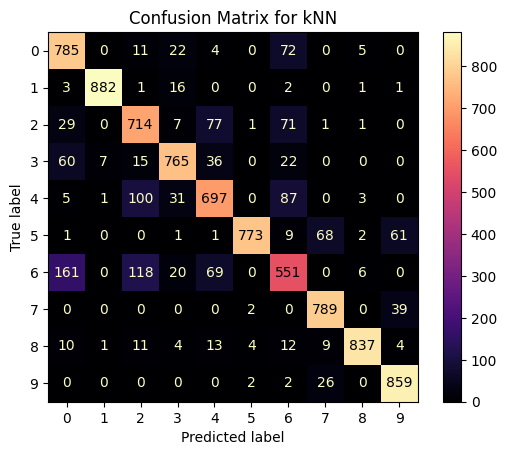

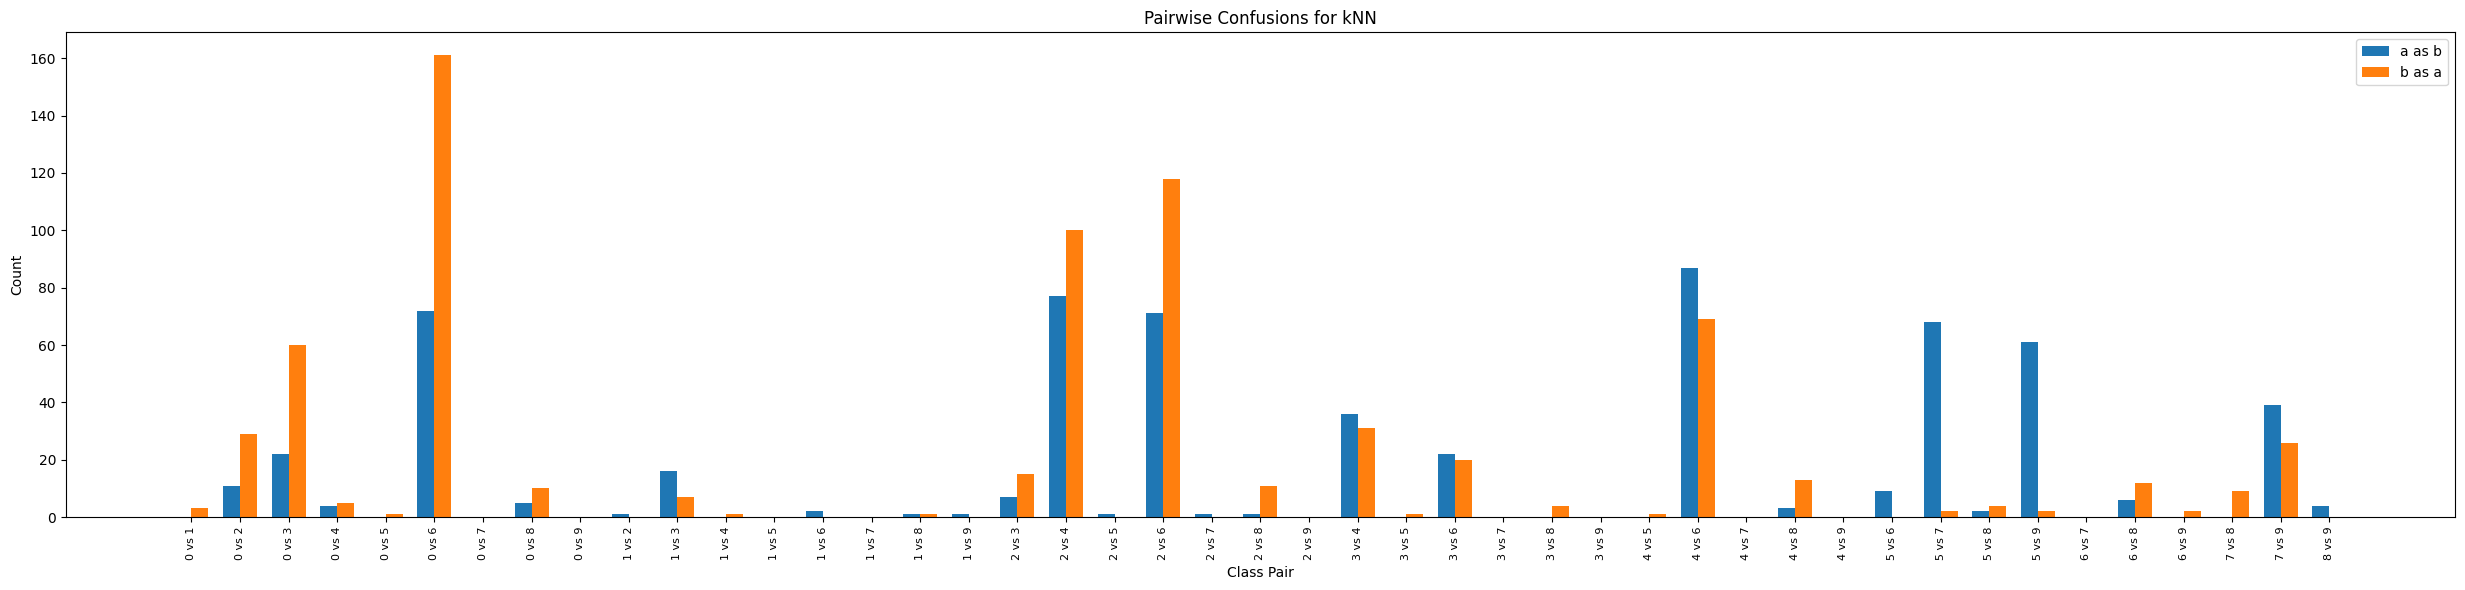

kNN class 0 AUC: 0.9594617399162053
kNN class 1 AUC: 0.9916313067592651
kNN class 2 AUC: 0.9318775601432825
kNN class 3 AUC: 0.9613418691709976
kNN class 4 AUC: 0.9333729461886965
kNN class 5 AUC: 0.9623190938378466
kNN class 6 AUC: 0.8643193707639527
kNN class 7 AUC: 0.9871057055639939
kNN class 8 AUC: 0.9789254672586242
kNN class 9 AUC: 0.9902099372333728


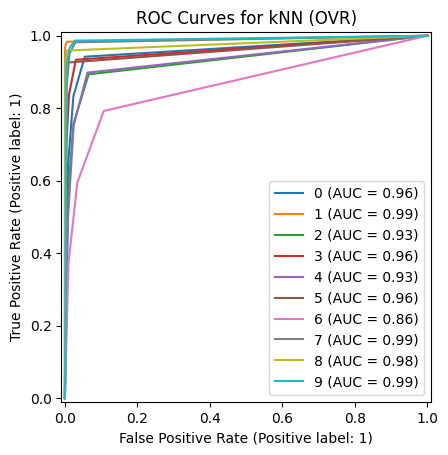

kNN pair 0 vs 7 AUC: 0.9909638554216867
kNN pair 0 vs 9 AUC: 0.9932508436445444
kNN pair 1 vs 5 AUC: 0.962882096069869


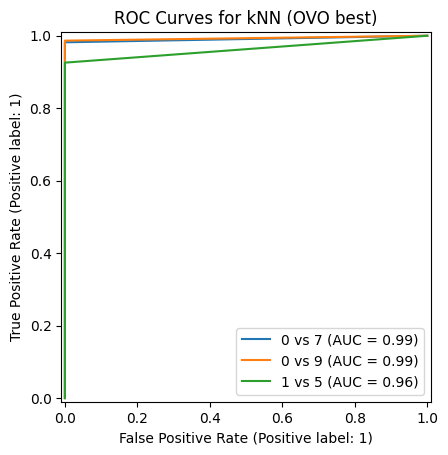

kNN pair 0 vs 6 AUC: 0.8178023629859001
kNN pair 2 vs 6 AUC: 0.8224081351051384
kNN pair 2 vs 4 AUC: 0.8918301454372486
kNN pair 4 vs 6 AUC: 0.8159868959868959
kNN pair 0 vs 3 AUC: 0.9549560899464722


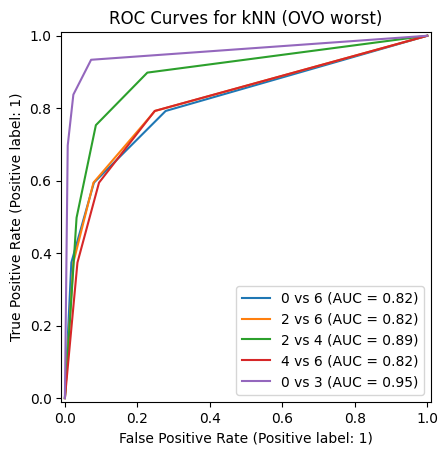

Validation time for kNN: 18.12 seconds


In [13]:
ke, kevals, k_eval_time = evaluate_model(k, "kNN", X_val, y_val, stage="validation", color="magma")
print(f"Validation time for kNN: {k_eval_time:.2f} seconds")

MLP Accuracy: 0.8858888888888888  Precision: 0.8856911759408207  Recall: 0.8858888888888888  F1 Score: 0.8856239996447487


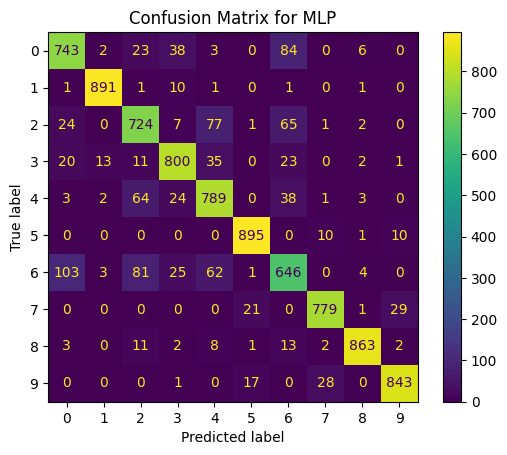

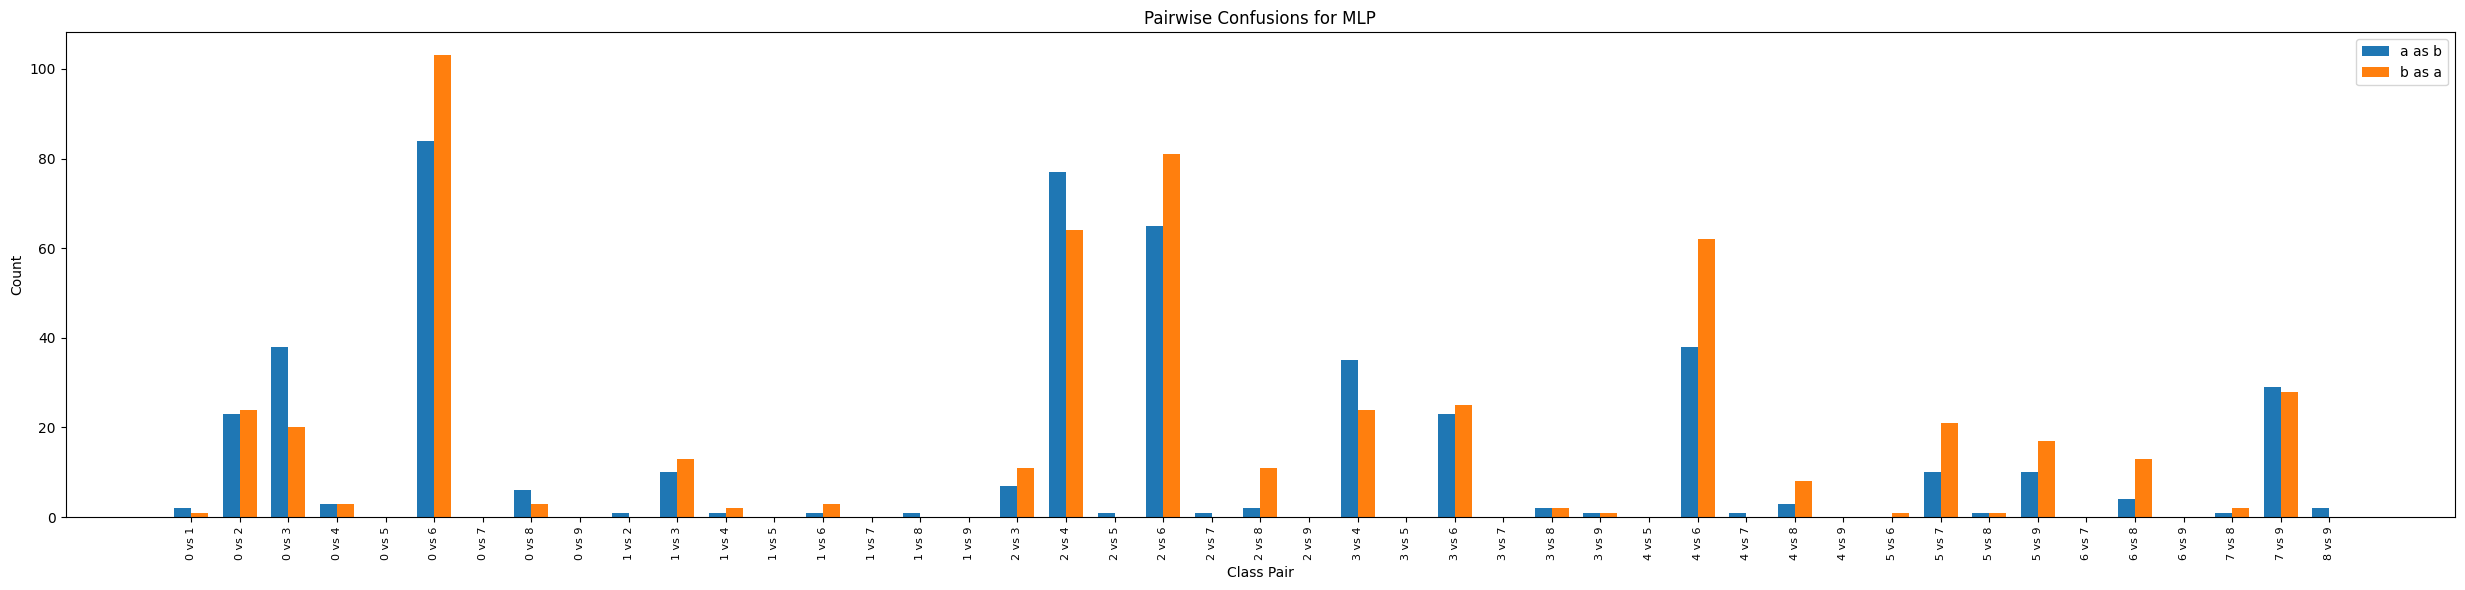

MLP class 0 AUC: 0.9869035243180542
MLP class 1 AUC: 0.9980446366670648
MLP class 2 AUC: 0.9790814941459044
MLP class 3 AUC: 0.9931166841273686
MLP class 4 AUC: 0.9854343691639381
MLP class 5 AUC: 0.9984061324434054
MLP class 6 AUC: 0.9676429420132207
MLP class 7 AUC: 0.9981995546445267
MLP class 8 AUC: 0.9968685396824313
MLP class 9 AUC: 0.9978530454621541


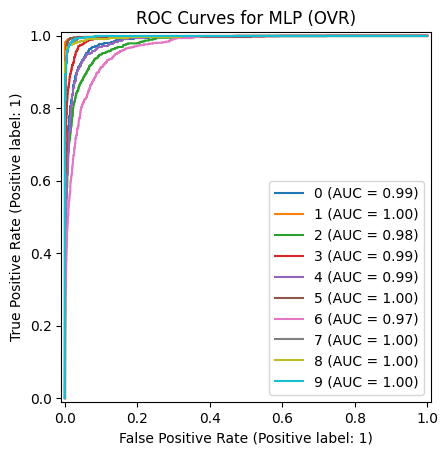

MLP pair 0 vs 5 AUC: 0.9991560248893725
MLP pair 0 vs 7 AUC: 0.9998954661806291
MLP pair 0 vs 9 AUC: 0.9989727368617298


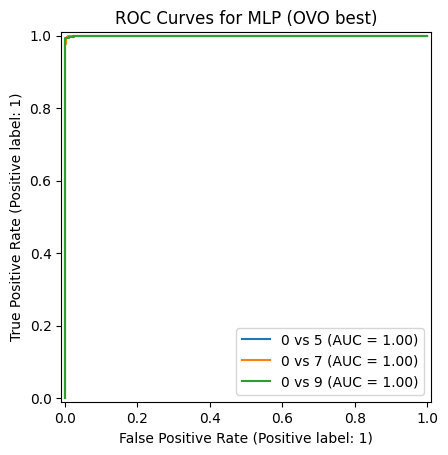

MLP pair 0 vs 6 AUC: 0.906699936866789
MLP pair 2 vs 6 AUC: 0.924362720100789
MLP pair 2 vs 4 AUC: 0.9454514224214556
MLP pair 4 vs 6 AUC: 0.9337217737217737
MLP pair 3 vs 4 AUC: 0.9778563057568582


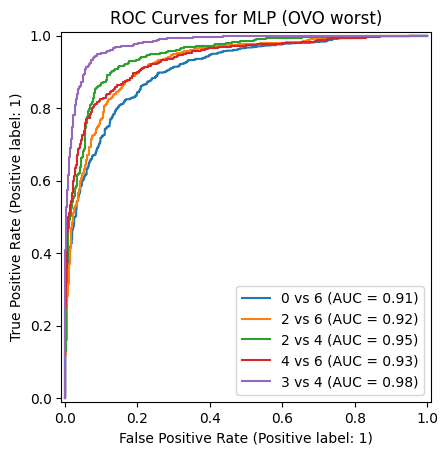

Validation time for MLP: 1.51 seconds


In [14]:
fe, fevals, fetime = evaluate_model(f, "MLP", X_val, y_val, stage="validation", color="viridis")
print(f"Validation time for MLP: {fetime:.2f} seconds")

71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
CNN Accuracy: 0.9034444444444445  Precision: 0.9032066070625974  Recall: 0.9034444444444445  F1 Score: 0.902957639887744


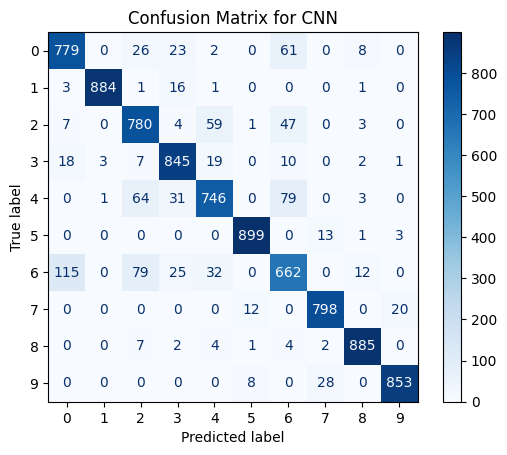

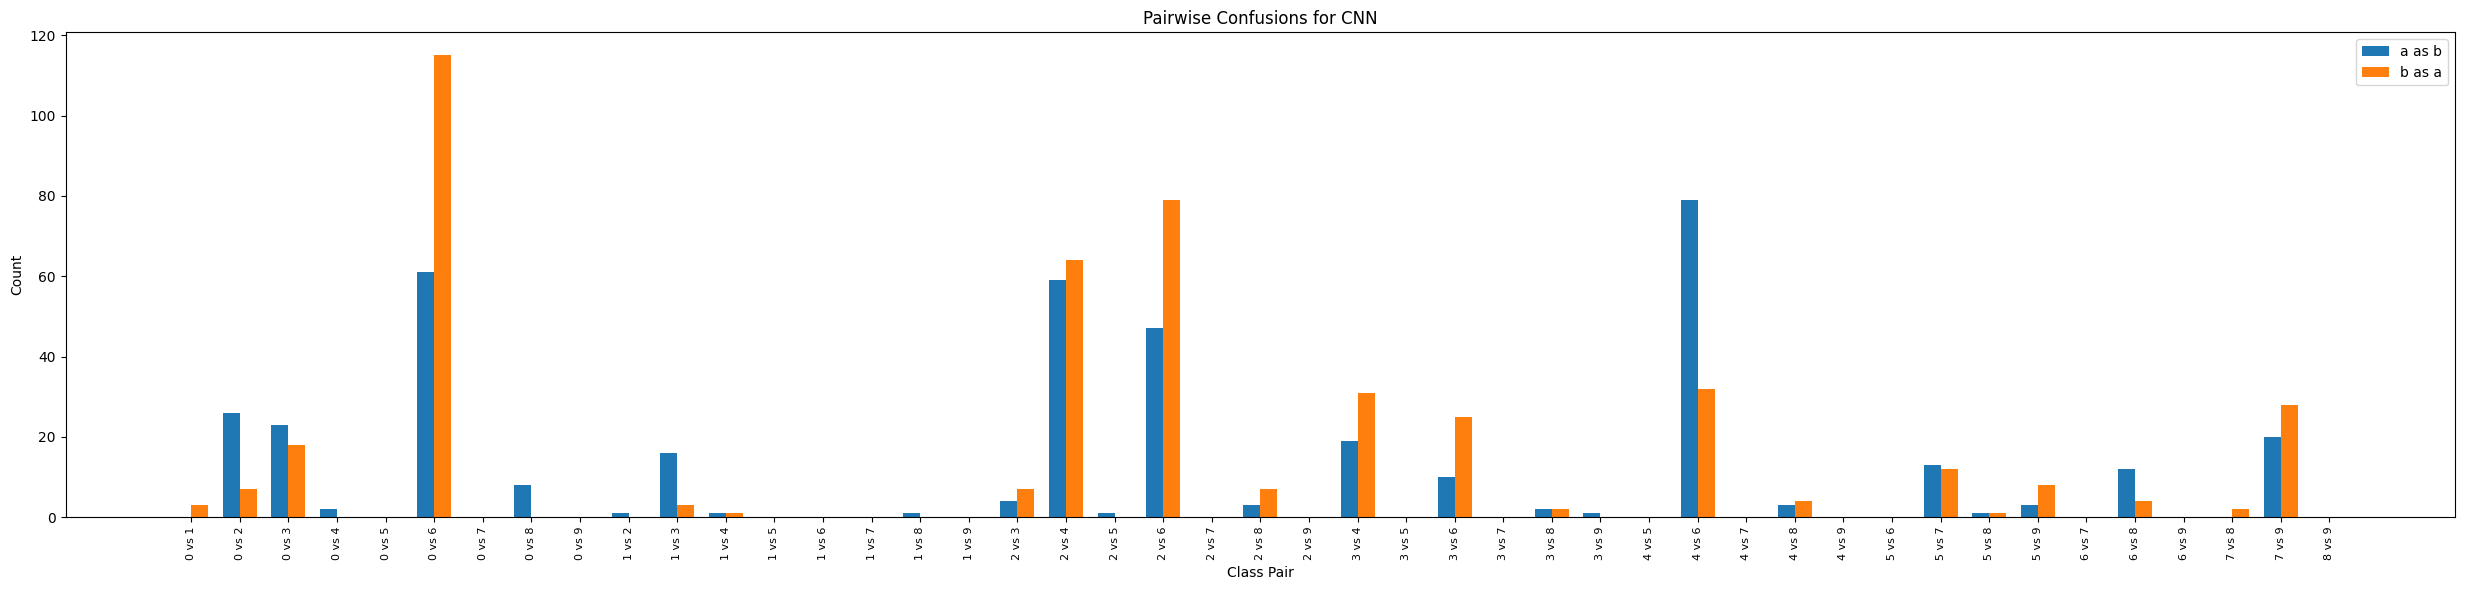

CNN class 0 AUC: 0.9907363913242697
CNN class 1 AUC: 0.9990717512931662
CNN class 2 AUC: 0.9879503080565569
CNN class 3 AUC: 0.9957510092513283
CNN class 4 AUC: 0.98804753113817
CNN class 5 AUC: 0.9995342301035632
CNN class 6 AUC: 0.9721621956321645
CNN class 7 AUC: 0.9990632788190705
CNN class 8 AUC: 0.999519654380475
CNN class 9 AUC: 0.999340006676209


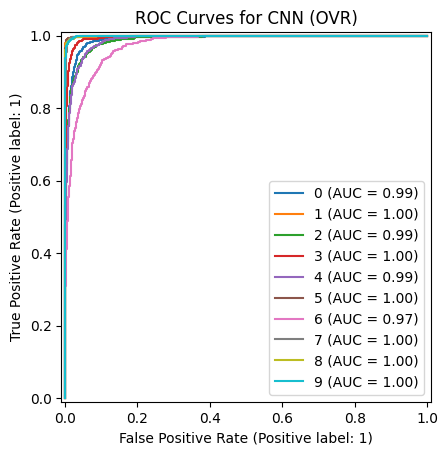

CNN pair 0 vs 5 AUC: 0.9998870652010239
CNN pair 0 vs 7 AUC: 0.9999865982282858
CNN pair 0 vs 9 AUC: 0.9999949950638818


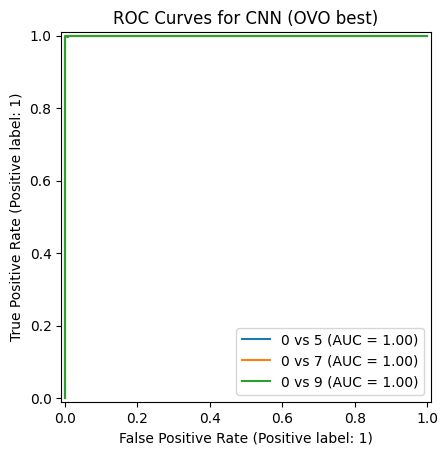

CNN pair 0 vs 6 AUC: 0.914381745482969
CNN pair 2 vs 6 AUC: 0.9415988241293457
CNN pair 2 vs 4 AUC: 0.9565646155546266
CNN pair 4 vs 6 AUC: 0.9222007722007722
CNN pair 3 vs 4 AUC: 0.9829972973619382


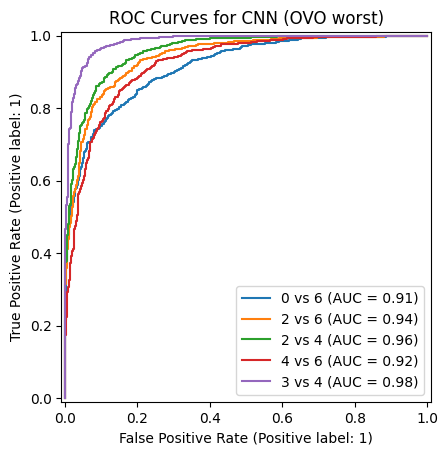

Validation time for CNN: 2.56 seconds


In [15]:
ce, cevals, ctime = evaluate_model(c, "CNN", X_val_cnn, y_val, stage="validation", color="Blues")
print(f"Validation time for CNN: {ctime:.2f} seconds")

Random Forest Accuracy: 0.8811111111111111  Precision: 0.8803659371337844  Recall: 0.8811111111111111  F1 Score: 0.8795212588749474


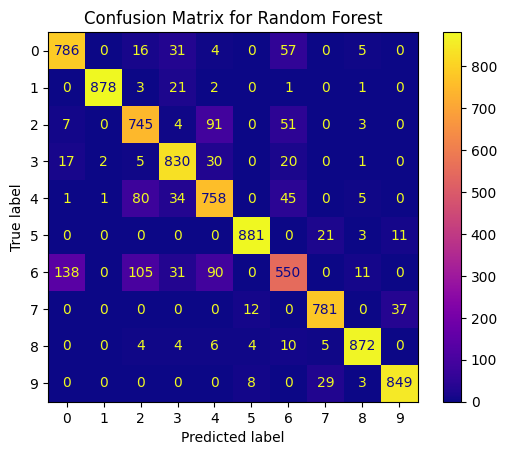

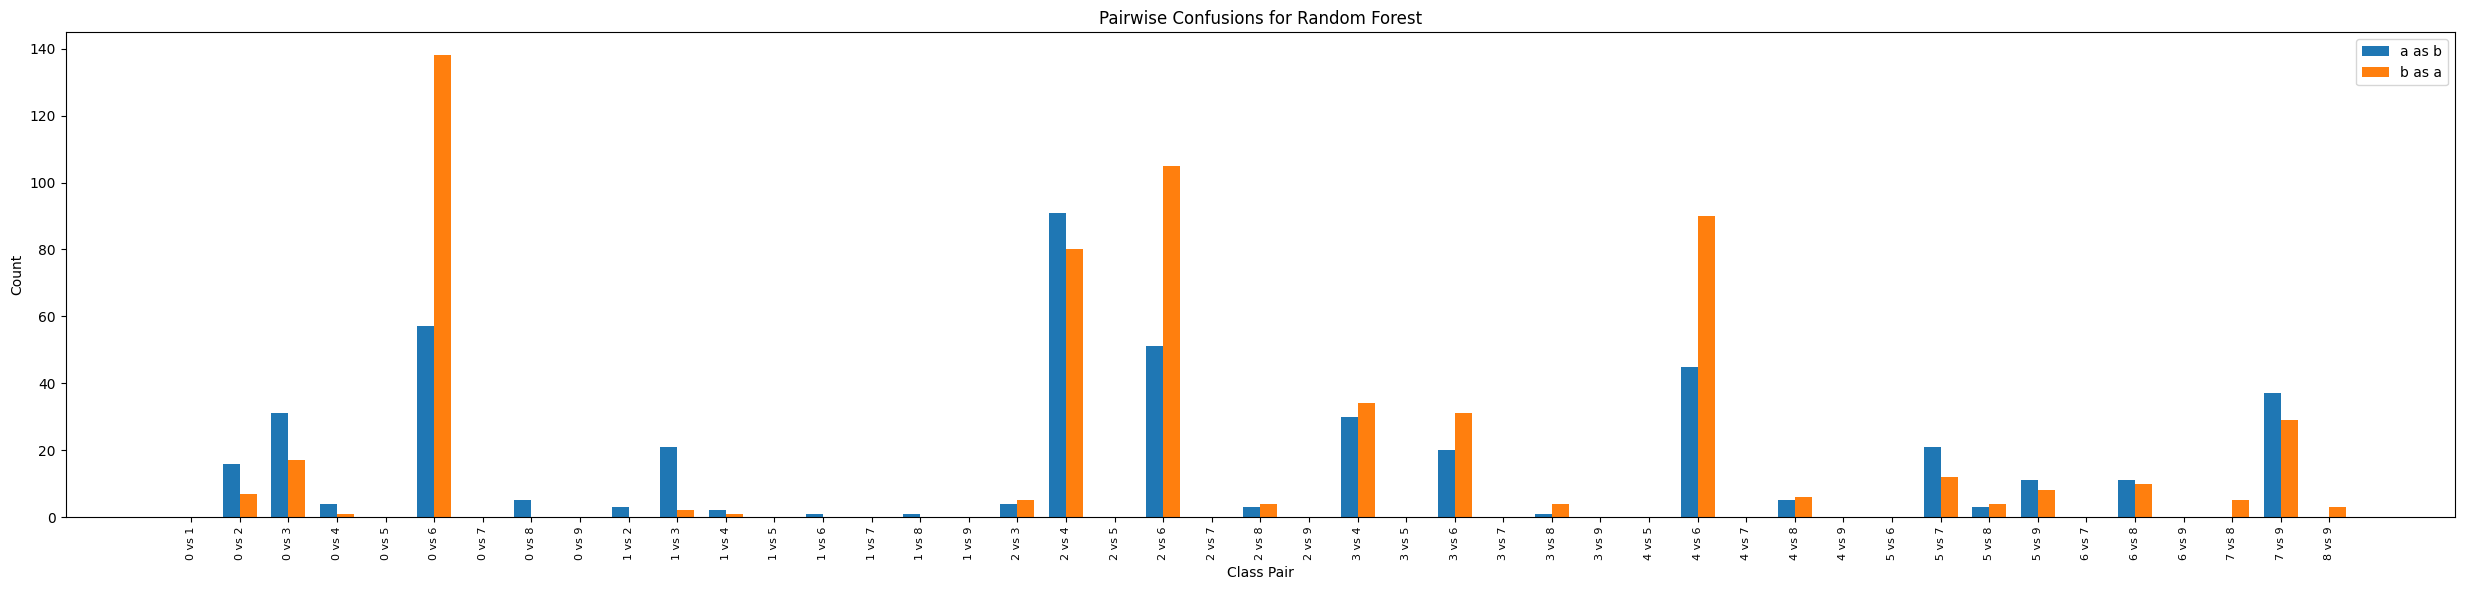

Random Forest class 0 AUC: 0.9900287650393758
Random Forest class 1 AUC: 0.998870951201964
Random Forest class 2 AUC: 0.9838917644975833
Random Forest class 3 AUC: 0.9946229000235463
Random Forest class 4 AUC: 0.9818971529131261
Random Forest class 5 AUC: 0.9994499620793891
Random Forest class 6 AUC: 0.9613964354447326
Random Forest class 7 AUC: 0.9981938033652358
Random Forest class 8 AUC: 0.9971723900231709
Random Forest class 9 AUC: 0.9987241146083469


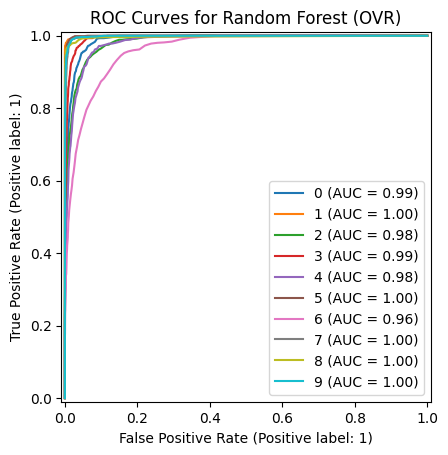

Random Forest pair 0 vs 1 AUC: 0.9988201263606606
Random Forest pair 0 vs 5 AUC: 0.9999829990625198
Random Forest pair 0 vs 7 AUC: 0.9999946392913144


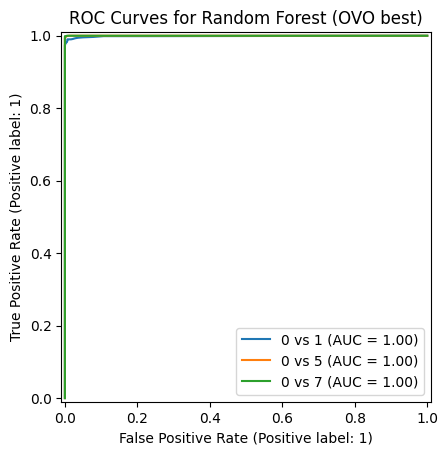

Random Forest pair 0 vs 6 AUC: 0.8777458437302708
Random Forest pair 2 vs 4 AUC: 0.9293990323402088
Random Forest pair 2 vs 6 AUC: 0.9047526772055073
Random Forest pair 4 vs 6 AUC: 0.9171539721539722
Random Forest pair 7 vs 9 AUC: 0.9907327849079106


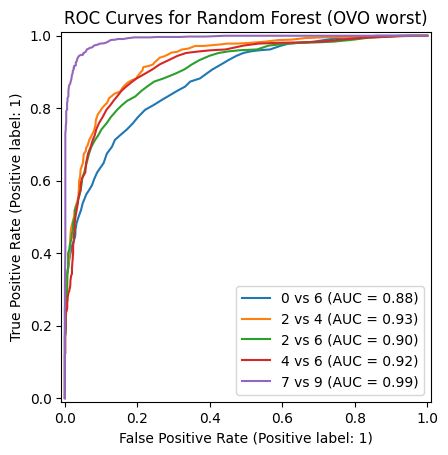

Validation time for Random Forest: 1.66 seconds


In [16]:
re, revals, retime = evaluate_model(r, "Random Forest", X_val, y_val, stage="validation", color="plasma")
print(f"Validation time for Random Forest: {retime:.2f} seconds")

# Final Testing and Evaluations

Logistic Regression Accuracy: 0.8328  Precision: 0.8310580588485158  Recall: 0.8328  F1 Score: 0.8317139700189049


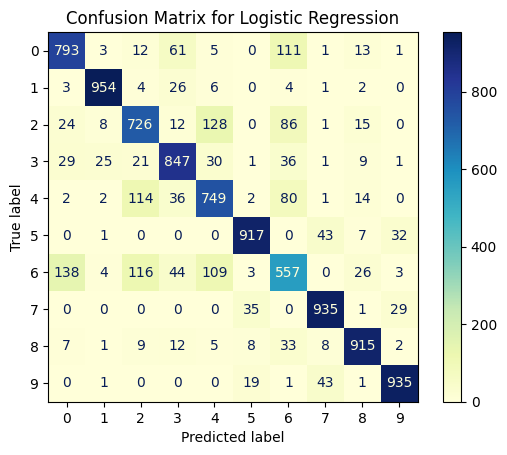

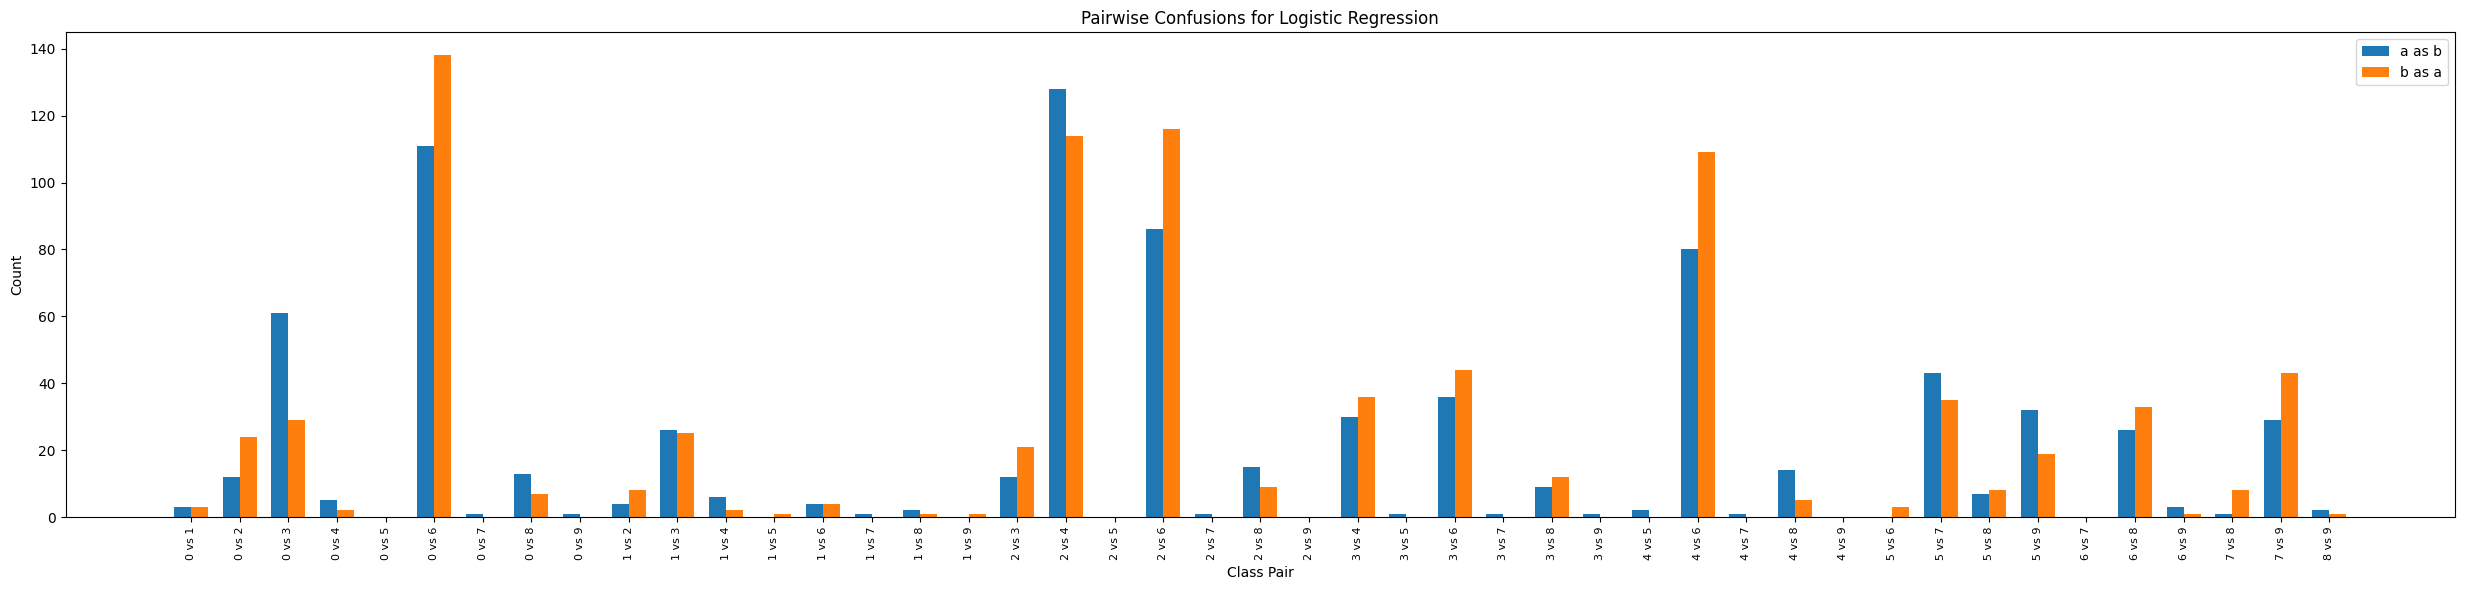

Logistic Regression class 0 AUC: 0.9784054444444445
Logistic Regression class 1 AUC: 0.9971707777777777
Logistic Regression class 2 AUC: 0.9679673333333334
Logistic Regression class 3 AUC: 0.9850721111111111
Logistic Regression class 4 AUC: 0.9714462222222222
Logistic Regression class 5 AUC: 0.9968155555555556
Logistic Regression class 6 AUC: 0.9267873333333333
Logistic Regression class 7 AUC: 0.9965171111111111
Logistic Regression class 8 AUC: 0.9896959999999999
Logistic Regression class 9 AUC: 0.9976686666666668


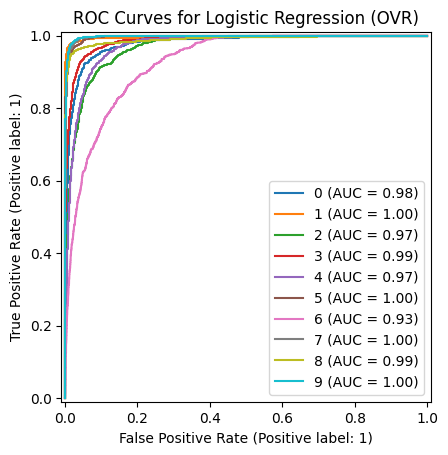

Logistic Regression pair 0 vs 5 AUC: 0.9996809999999999
Logistic Regression pair 2 vs 5 AUC: 0.9997809999999999
Logistic Regression pair 2 vs 9 AUC: 0.999936


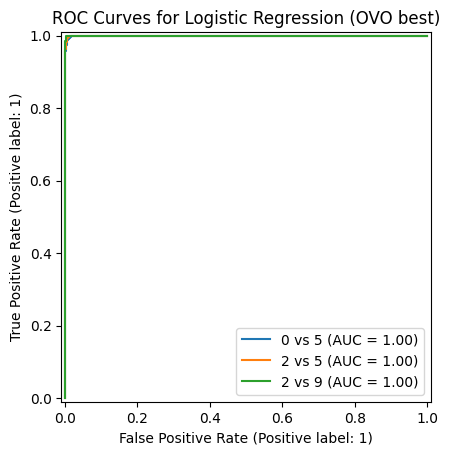

Logistic Regression pair 0 vs 6 AUC: 0.81155
Logistic Regression pair 2 vs 4 AUC: 0.8968889999999998
Logistic Regression pair 2 vs 6 AUC: 0.816109
Logistic Regression pair 4 vs 6 AUC: 0.8362480000000001
Logistic Regression pair 0 vs 3 AUC: 0.9635139999999999


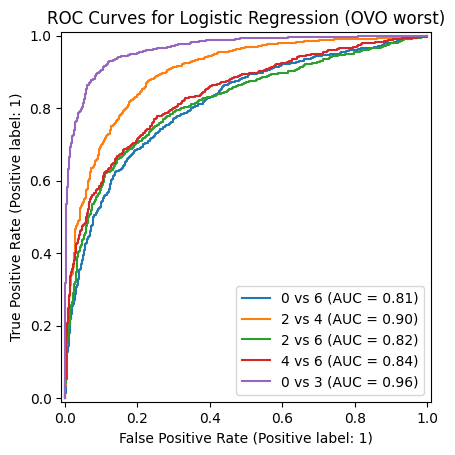

Test time for Logistic Regression: 1.54 seconds


In [17]:
le_test, le_test_vals, le_test_time = evaluate_model(l, "Logistic Regression", X_test, y_test, stage="test", color="YlGnBu")
print(f"Test time for Logistic Regression: {le_test_time:.2f} seconds")

kNN Accuracy: 0.848  Precision: 0.8511550621961887  Recall: 0.848  F1 Score: 0.8482031657959469


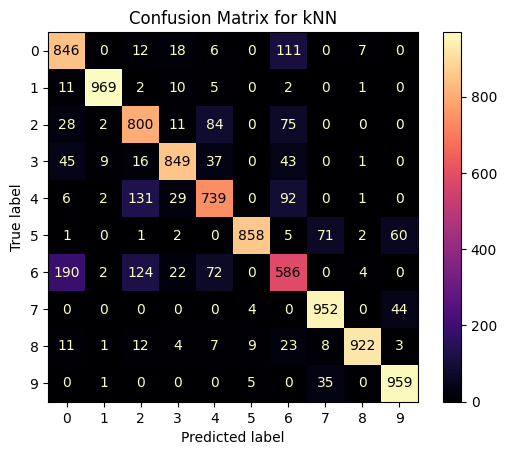

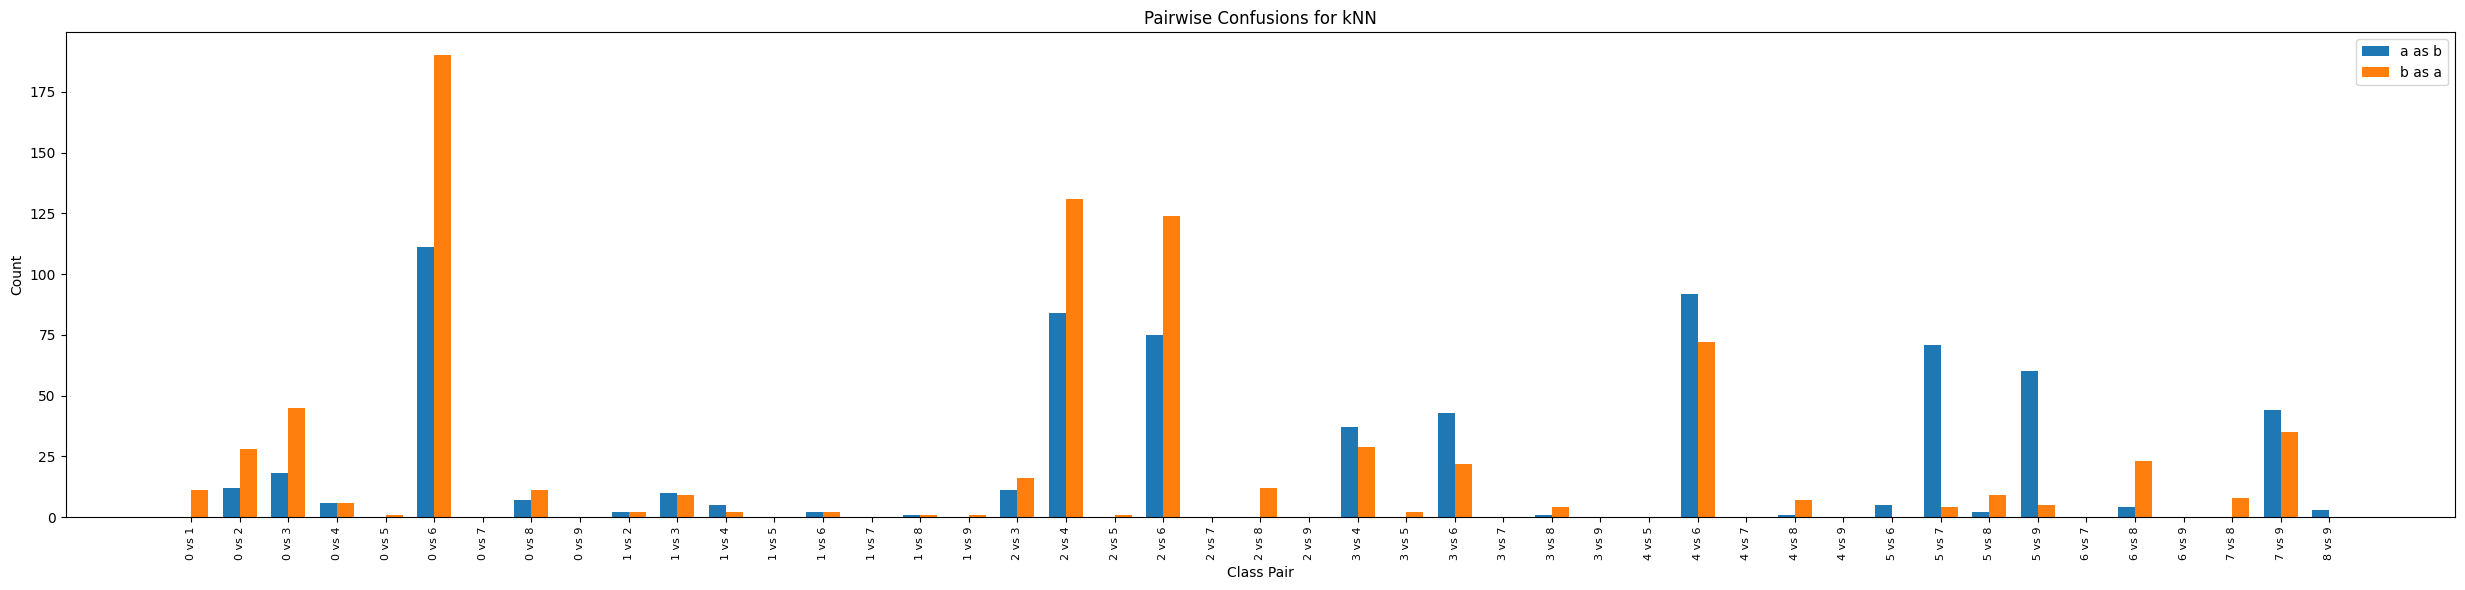

kNN class 0 AUC: 0.9530582222222223
kNN class 1 AUC: 0.9902855555555555
kNN class 2 AUC: 0.9374491111111111
kNN class 3 AUC: 0.961094
kNN class 4 AUC: 0.9318661111111112
kNN class 5 AUC: 0.9604700555555556
kNN class 6 AUC: 0.8668541666666667
kNN class 7 AUC: 0.9894713333333334
kNN class 8 AUC: 0.9774595555555555
kNN class 9 AUC: 0.9894232222222221


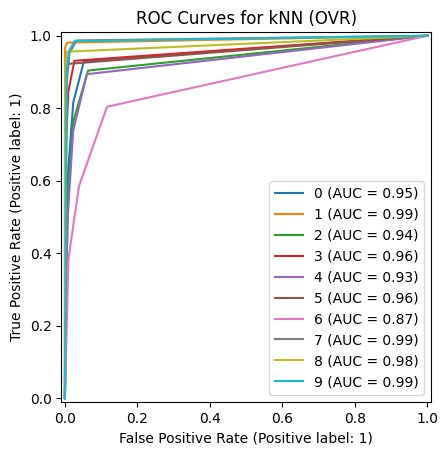

kNN pair 0 vs 7 AUC: 0.9934520000000001
kNN pair 0 vs 9 AUC: 0.9924999999999999
kNN pair 1 vs 5 AUC: 0.9610000000000001


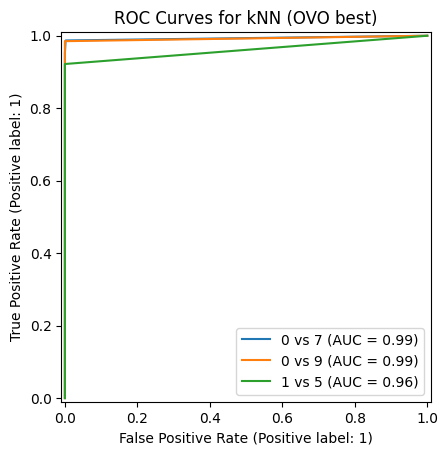

kNN pair 0 vs 6 AUC: 0.8060510000000001
kNN pair 2 vs 4 AUC: 0.890902
kNN pair 2 vs 6 AUC: 0.8292600000000001
kNN pair 4 vs 6 AUC: 0.8183395
kNN pair 7 vs 9 AUC: 0.9827135


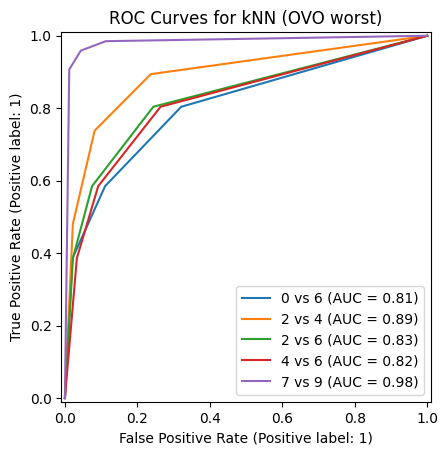

Test time for kNN: 17.57 seconds


In [18]:
ke_test, ke_test_vals, ke_test_time = evaluate_model(k, "kNN", X_test, y_test, stage="test", color="magma")
print(f"Test time for kNN: {ke_test_time:.2f} seconds")

MLP Accuracy: 0.8816  Precision: 0.8812609280997827  Recall: 0.8816  F1 Score: 0.8813201568683917


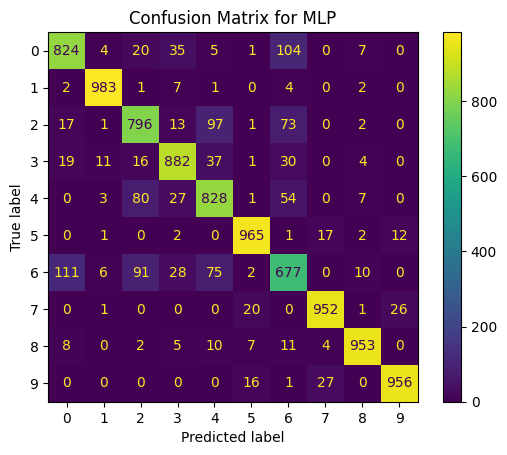

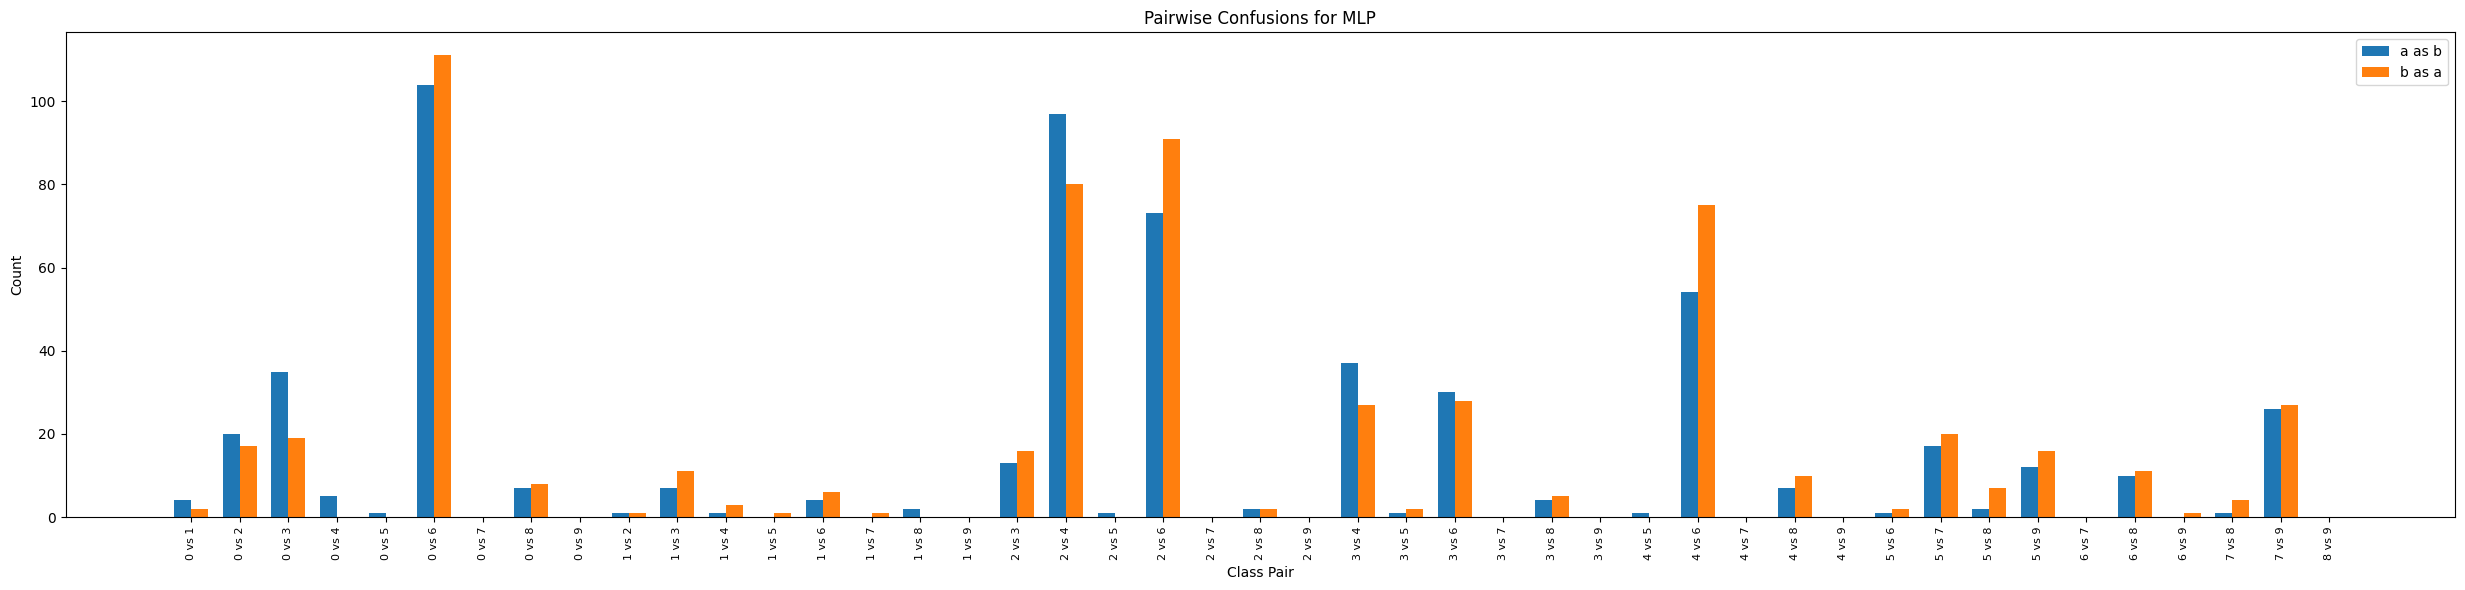

MLP class 0 AUC: 0.9842820555555555
MLP class 1 AUC: 0.9988272222222222
MLP class 2 AUC: 0.9769868888888888
MLP class 3 AUC: 0.9918031111111112
MLP class 4 AUC: 0.9828826666666668
MLP class 5 AUC: 0.9989038888888889
MLP class 6 AUC: 0.9576273333333334
MLP class 7 AUC: 0.9987010000000001
MLP class 8 AUC: 0.9962937777777777
MLP class 9 AUC: 0.9988191111111112


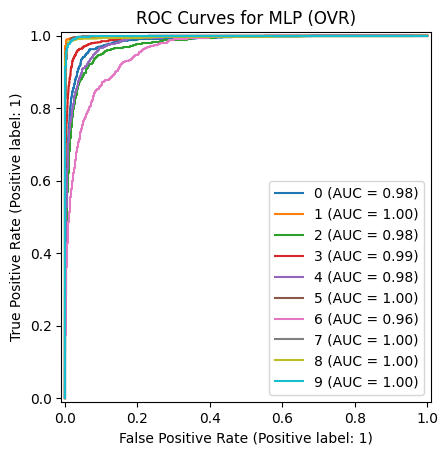

MLP pair 0 vs 7 AUC: 0.999956
MLP pair 0 vs 9 AUC: 0.999838
MLP pair 1 vs 9 AUC: 0.999934


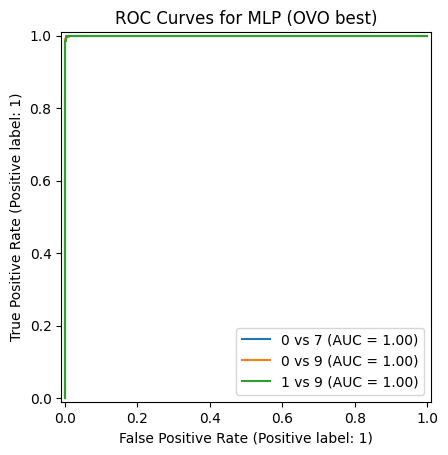

MLP pair 0 vs 6 AUC: 0.873551
MLP pair 2 vs 4 AUC: 0.939942
MLP pair 2 vs 6 AUC: 0.905312
MLP pair 4 vs 6 AUC: 0.909363
MLP pair 3 vs 4 AUC: 0.9738629999999999


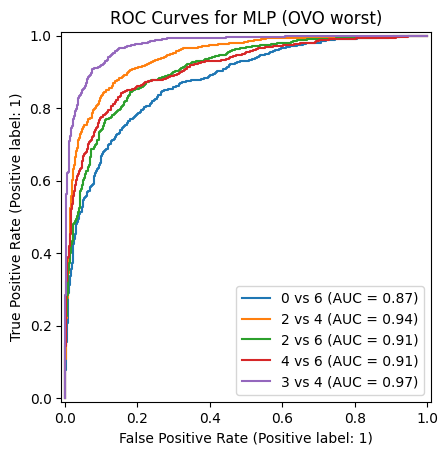

Test time for MLP: 1.26 seconds


In [19]:
fe_test, fe_test_vals, fe_test_time = evaluate_model(f, "MLP", X_test, y_test, stage="test", color="viridis")
print(f"Test time for MLP: {fe_test_time:.2f} seconds")

79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
CNN Accuracy: 0.8962  Precision: 0.8959674964948215  Recall: 0.8962  F1 Score: 0.8958903085447508


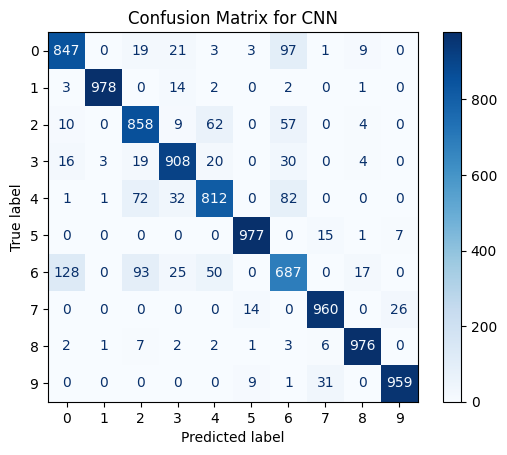

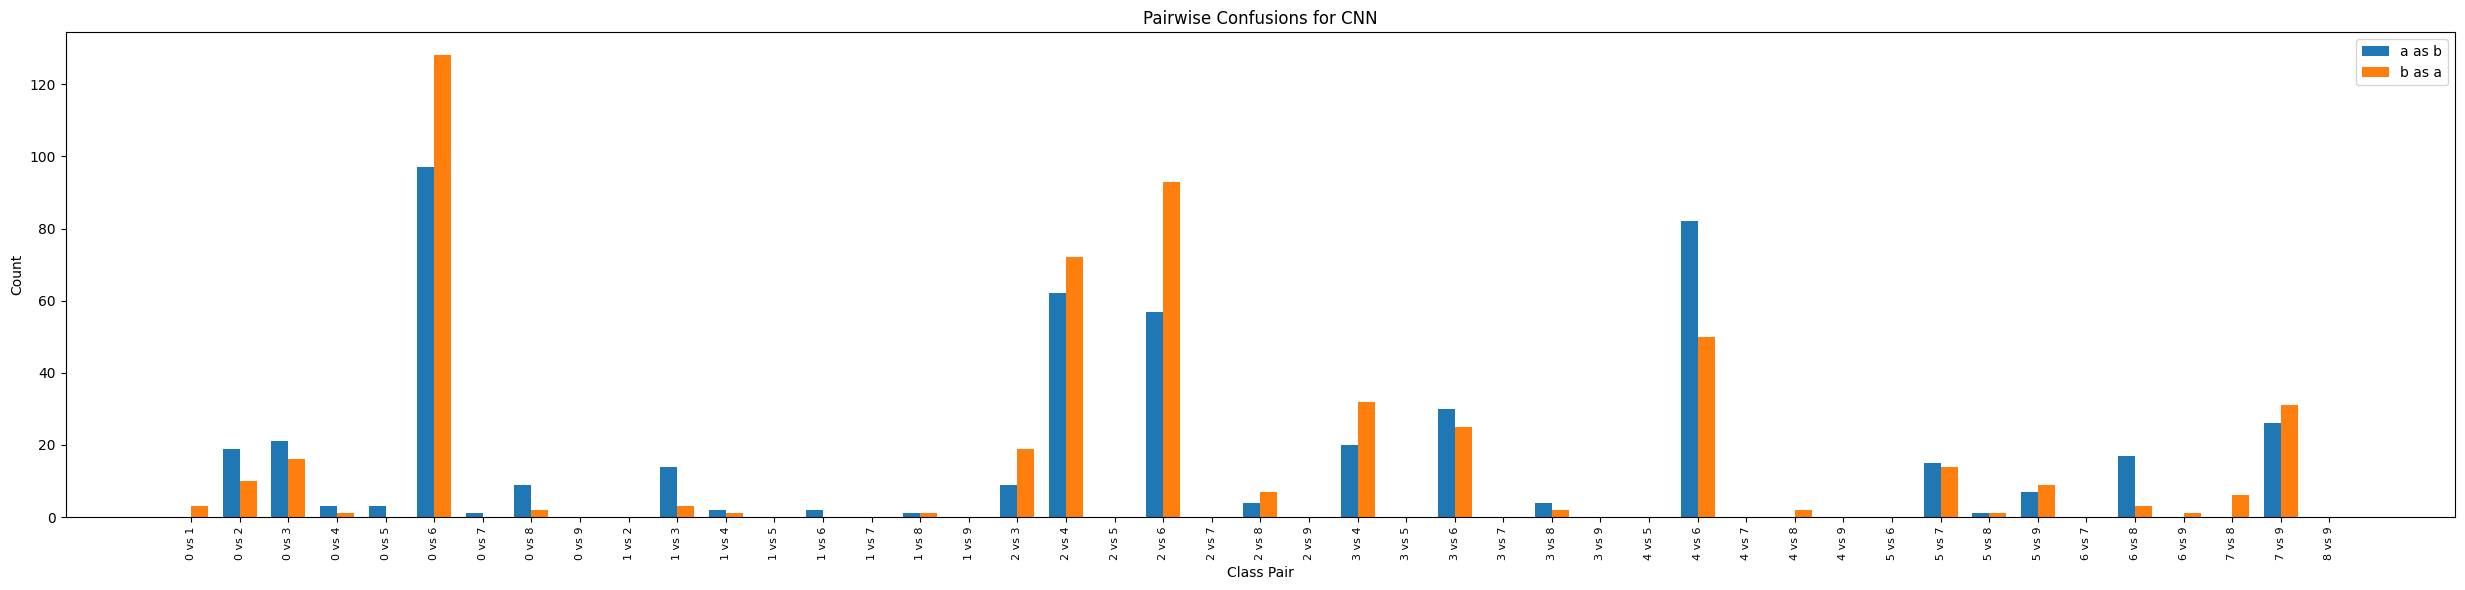

CNN class 0 AUC: 0.9901768888888889
CNN class 1 AUC: 0.9992882222222222
CNN class 2 AUC: 0.9862788888888889
CNN class 3 AUC: 0.9955599444444444
CNN class 4 AUC: 0.9890505555555554
CNN class 5 AUC: 0.9996252777777778
CNN class 6 AUC: 0.9662480000000001
CNN class 7 AUC: 0.9988277777777778
CNN class 8 AUC: 0.9990696666666666
CNN class 9 AUC: 0.9992621111111112


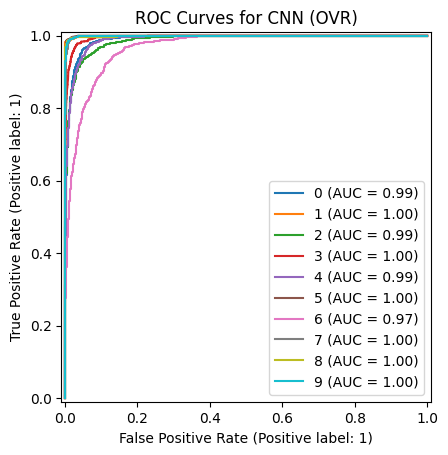

CNN pair 0 vs 9 AUC: 0.9999049999999999
CNN pair 1 vs 2 AUC: 0.999333
CNN pair 1 vs 5 AUC: 0.999992


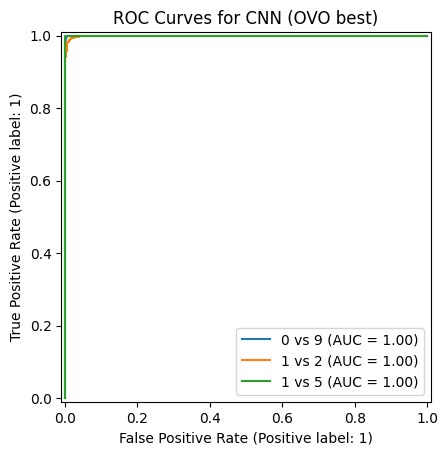

CNN pair 0 vs 6 AUC: 0.892861
CNN pair 2 vs 6 AUC: 0.9294609999999999
CNN pair 2 vs 4 AUC: 0.9589650000000001
CNN pair 4 vs 6 AUC: 0.9123669999999999
CNN pair 7 vs 9 AUC: 0.995219


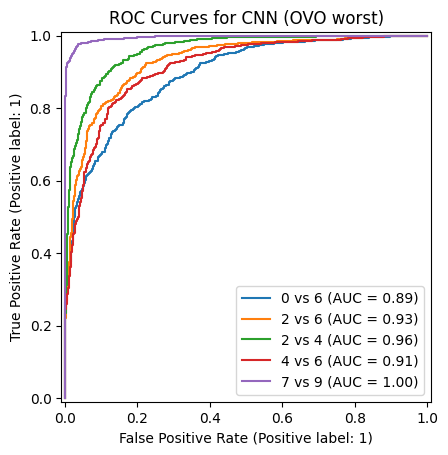

Test time for CNN: 2.46 seconds


In [20]:
ce_test, ce_test_vals, ce_test_time = evaluate_model(c, "CNN", X_test_cnn, y_test, stage="test", color="Blues")
print(f"Test time for CNN: {ce_test_time:.2f} seconds")

Random Forest Accuracy: 0.8745  Precision: 0.8735597747945514  Recall: 0.8745  F1 Score: 0.8730501086913438


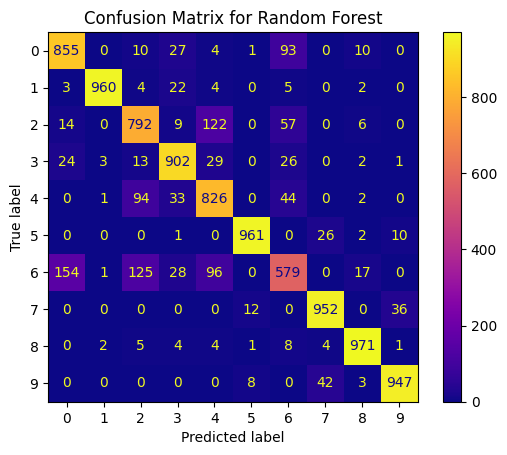

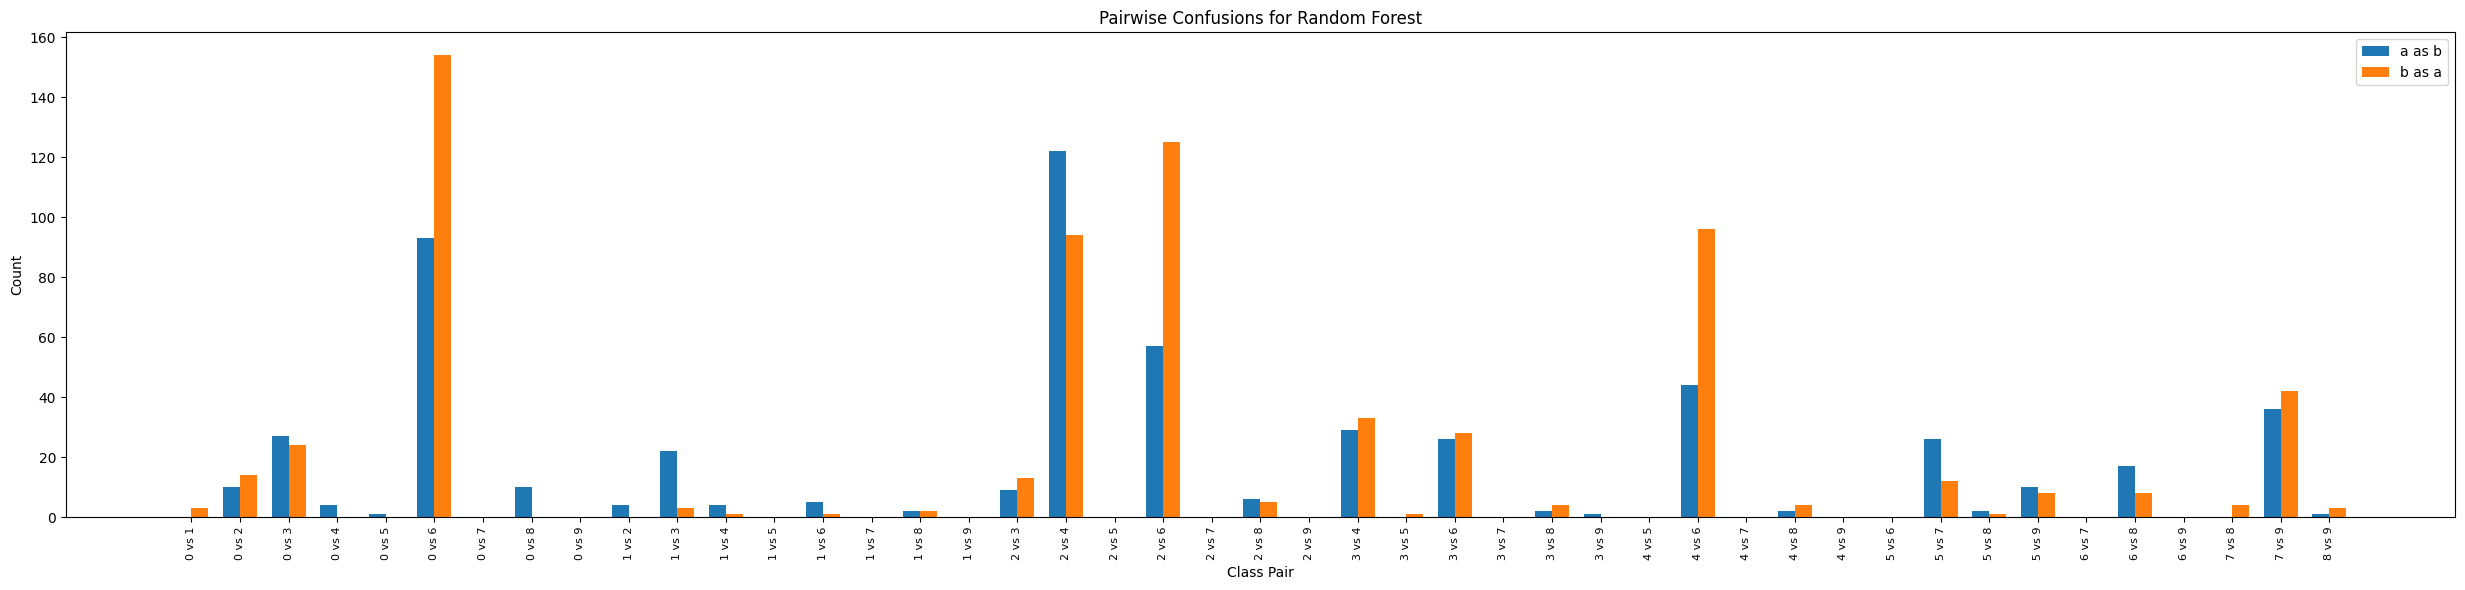

Random Forest class 0 AUC: 0.9870852777777778
Random Forest class 1 AUC: 0.9986050555555556
Random Forest class 2 AUC: 0.9803160555555557
Random Forest class 3 AUC: 0.9933369999999999
Random Forest class 4 AUC: 0.9830485555555555
Random Forest class 5 AUC: 0.9992593888888889
Random Forest class 6 AUC: 0.9556188888888889
Random Forest class 7 AUC: 0.9981622777777779
Random Forest class 8 AUC: 0.9975573888888889
Random Forest class 9 AUC: 0.998534


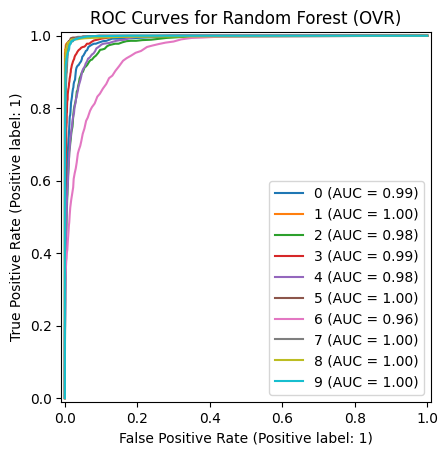

Random Forest pair 0 vs 7 AUC: 0.9999945
Random Forest pair 0 vs 9 AUC: 0.999959
Random Forest pair 1 vs 5 AUC: 0.9999945


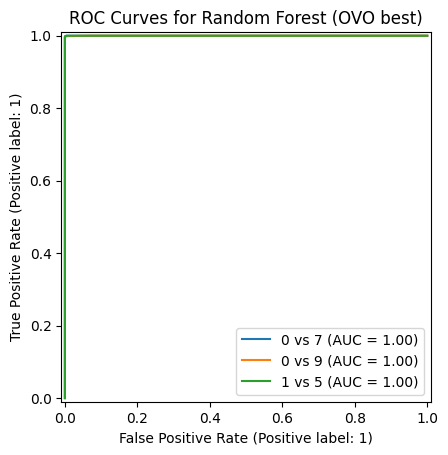

Random Forest pair 0 vs 6 AUC: 0.8525950000000001
Random Forest pair 2 vs 4 AUC: 0.9276565
Random Forest pair 2 vs 6 AUC: 0.894685
Random Forest pair 4 vs 6 AUC: 0.9113480000000002
Random Forest pair 7 vs 9 AUC: 0.9910135000000001


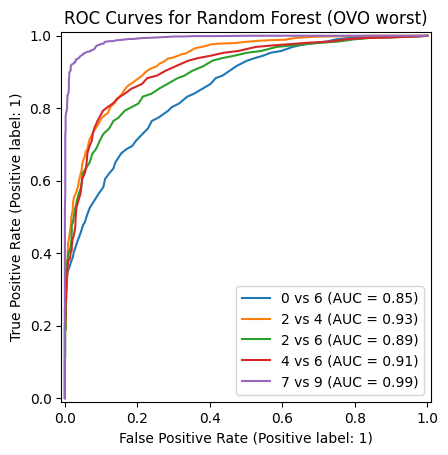

Test time for Random Forest: 1.83 seconds


In [21]:
re_test, re_test_vals, re_test_time = evaluate_model(r, "Random Forest", X_test, y_test, stage="test", color="plasma")
print(f"Test time for Random Forest: {re_test_time:.2f} seconds")

# Comparing All Models

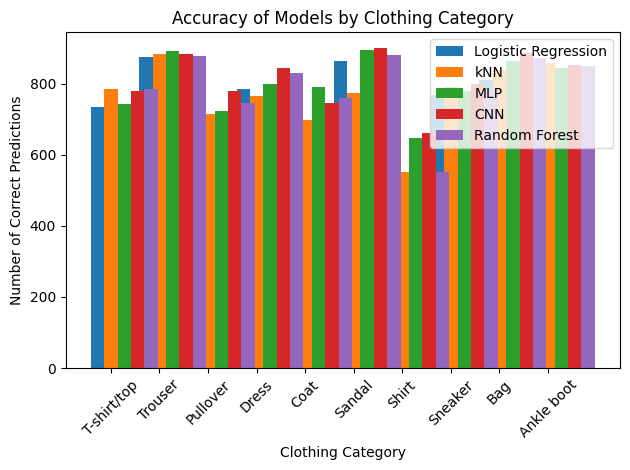

In [22]:
models = ["Logistic Regression", "kNN", "MLP", "CNN", "Random Forest"]
catcounts = {"Logistic Regression": np.diag(levals.cm) , "kNN": np.diag(kevals.cm) , "MLP": np.diag(fevals.cm), "CNN": np.diag(cevals.cm), "Random Forest": np.diag(revals.cm)}
cataccs = {model: counts/(len(y_test)/len(clothing_types)) for model, counts in catcounts.items()}

# Graph the numeric accuracies
x = np.arange(len(clothing_types))
width = 0.275
[plt.bar(x - width + i*width, catcounts[model], width, label=model) for i, model in enumerate(models)]
plt.xlabel('Clothing Category')
plt.ylabel('Number of Correct Predictions')
plt.title('Accuracy of Models by Clothing Category')
plt.xticks(x, [clothing_types[i] for i in clothing_types.keys()], rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig('figures/model_category_accuracies.png')
plt.show()

In [23]:
[print(f"{model} Category Accuracy: {cataccs[model]}") for model in models]
totaccs = {model: np.round(np.mean(cataccs[model]), 4) for model in models}
print("Sorted by Overall Accuracy:", sorted([{"Logistic Regression": totaccs["Logistic Regression"]}, {"kNN": totaccs["kNN"]}, {"MLP": totaccs["MLP"]}, {"CNN": totaccs["CNN"]} , {"Random Forest": totaccs["Random Forest"]}], key=lambda x: list(x.values())[0], reverse=True))

Logistic Regression Category Accuracy: [0.734 0.874 0.657 0.786 0.712 0.862 0.53  0.768 0.811 0.828]
kNN Category Accuracy: [0.785 0.882 0.714 0.765 0.697 0.773 0.551 0.789 0.837 0.859]
MLP Category Accuracy: [0.743 0.891 0.724 0.8   0.789 0.895 0.646 0.779 0.863 0.843]
CNN Category Accuracy: [0.779 0.884 0.78  0.845 0.746 0.899 0.662 0.798 0.885 0.853]
Random Forest Category Accuracy: [0.786 0.878 0.745 0.83  0.758 0.881 0.55  0.781 0.872 0.849]
Sorted by Overall Accuracy: [{'CNN': np.float64(0.8131)}, {'MLP': np.float64(0.7973)}, {'Random Forest': np.float64(0.793)}, {'kNN': np.float64(0.7652)}, {'Logistic Regression': np.float64(0.7562)}]


In [24]:
performance_by_category = pd.DataFrame({model: cataccs[model] for model in models}, index=[clothing_types[i] for i in clothing_types.keys()])
print("Performance by Category:", performance_by_category, sep="\n")
print("\nSorted by Category Accuracy:")
for category in performance_by_category.index:
    sorted_models = performance_by_category.loc[category].sort_values(ascending=False)
    print(f"Category {category}: {sorted_models.to_dict()}")

Performance by Category:
             Logistic Regression    kNN    MLP    CNN  Random Forest
T-shirt/top                0.734  0.785  0.743  0.779          0.786
Trouser                    0.874  0.882  0.891  0.884          0.878
Pullover                   0.657  0.714  0.724  0.780          0.745
Dress                      0.786  0.765  0.800  0.845          0.830
Coat                       0.712  0.697  0.789  0.746          0.758
Sandal                     0.862  0.773  0.895  0.899          0.881
Shirt                      0.530  0.551  0.646  0.662          0.550
Sneaker                    0.768  0.789  0.779  0.798          0.781
Bag                        0.811  0.837  0.863  0.885          0.872
Ankle boot                 0.828  0.859  0.843  0.853          0.849

Sorted by Category Accuracy:
Category T-shirt/top: {'Random Forest': 0.786, 'kNN': 0.785, 'CNN': 0.779, 'MLP': 0.743, 'Logistic Regression': 0.734}
Category Trouser: {'MLP': 0.891, 'CNN': 0.884, 'kNN': 0.882, 'Rando

In [25]:
best_model_by_category = performance_by_category.idxmax(axis=1)
print(f"Best model by category:", best_model_by_category, sep="\n")
print(f"Model best performace counts by category: \n{best_model_by_category.value_counts()}")
print(f"Model with most category wins: {best_model_by_category.value_counts().idxmax()}")

Best model by category:
T-shirt/top    Random Forest
Trouser                  MLP
Pullover                 CNN
Dress                    CNN
Coat                     MLP
Sandal                   CNN
Shirt                    CNN
Sneaker                  CNN
Bag                      CNN
Ankle boot               kNN
dtype: object
Model best performace counts by category: 
CNN              6
MLP              2
Random Forest    1
kNN              1
Name: count, dtype: int64
Model with most category wins: CNN
